In [28]:
import subprocess
from shlex import split

In [29]:
bedpe_path = "/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/stripenn_eed/score_awked.tsv"

In [30]:
cmd = fr"""awk 'BEGIN{{FS=OFS="\t"}} !/^#/ {{c[$1]++; c[$4]++}}
           END{{for(chr in c) print chr, c[chr]}}' {bedpe_path} |
           sort -t$'\t' -k1,1V"""

In [31]:
subprocess.run(cmd, shell=True, check=True)

chr1	232
chr2	242
chr3	184
chr4	140
chr5	144
chr6	174
chr7	142
chr8	132
chr9	86
chr10	102
chr11	150
chr12	134
chr13	44
chr14	54
chr15	62
chr16	52
chr17	76
chr18	48
chr19	34
chr20	62
chr21	18
chr22	12


CompletedProcess(args='awk \'BEGIN{FS=OFS="\\t"} !/^#/ {c[$1]++; c[$4]++}\n           END{for(chr in c) print chr, c[chr]}\' /usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/stripenn_eed/score_awked.tsv |\n           sort -t$\'\\t\' -k1,1V', returncode=0)

In [32]:
awk_output = subprocess.run(cmd, shell=True, check=True, capture_output=True).stdout.decode("utf-8")
awk_output

'chr1\t232\nchr2\t242\nchr3\t184\nchr4\t140\nchr5\t144\nchr6\t174\nchr7\t142\nchr8\t132\nchr9\t86\nchr10\t102\nchr11\t150\nchr12\t134\nchr13\t44\nchr14\t54\nchr15\t62\nchr16\t52\nchr17\t76\nchr18\t48\nchr19\t34\nchr20\t62\nchr21\t18\nchr22\t12\n'

In [33]:
import pandas as pd, matplotlib.pyplot as plt
from tempfile import TemporaryFile

with TemporaryFile() as f:
    subprocess.run(cmd, shell=True, check=True, stdout=f)
    f.seek(0)
    #print(f.read().decode("utf-8"))
    df = pd.read_csv(
        f, sep=r"\s+", header=None, names=["chrom", "count"],
)

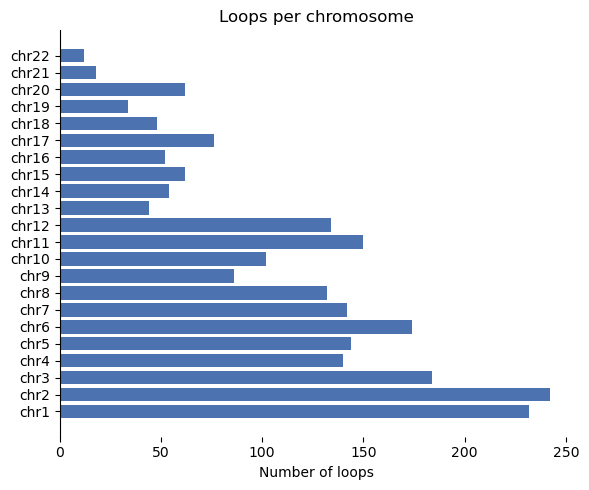

In [34]:
plt.figure(figsize=(6, 5))
bars = plt.barh(df["chrom"], df["count"], color="#4C72B0")
#for bar in bars:
#    width = bar.get_width()                                  # x-value
#    ycent = bar.get_y() + bar.get_height() / 2               # y-centre
#    plt.text(width + 40, ycent, f"{width:,}", va="center")   # 40-px offset

ax = plt.gca()                           # current axes
for side in ("top", "right", "bottom"):
    ax.spines[side].set_visible(False)

plt.xlabel("Number of loops")
plt.title("Loops per chromosome")
plt.tight_layout()
plt.show()

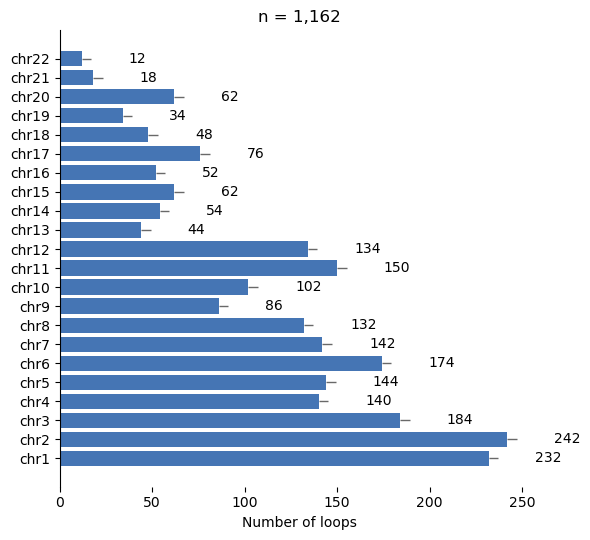

In [35]:
fig, ax = plt.subplots(figsize=(6, 5.5))
bars = ax.barh(df["chrom"], df["count"], color="#4575b4")

for bar in bars:
    w  = bar.get_width()
    yc = bar.get_y() + bar.get_height()/2

    # small line (2 % of the x-axis range)
    tick_len = 0.02 * ax.get_xlim()[1]
    ax.hlines(yc, w, w + tick_len, color="dimgray", linewidth=1)

    # label just past the tick
    ax.text(w + tick_len + 20, yc, f"{int(w):,}",
            va="center", color='black', fontsize=10)

# tidy axes
for side in ("top", "right", "bottom"):
    ax.spines[side].set_visible(False)

ax.set_xlabel("Number of loops")
ax.set_title(f"n = {df['count'].sum()//2:,}")
#ax = plt.gca()
#ax.tick_params(axis="x", bottom=False, labelbottom=False)
#ax.spines["bottom"].set_visible(False)
plt.tight_layout()
plt.show()

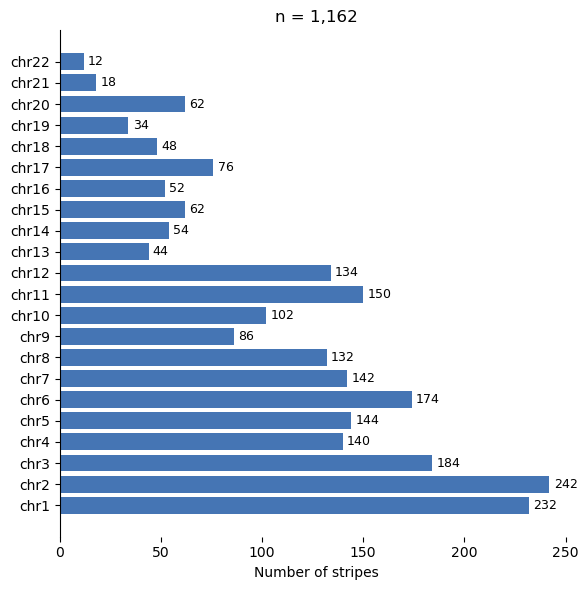

In [36]:
fig, ax = plt.subplots(figsize=(6, 6))

bars = ax.barh(df["chrom"], df["count"], color="#4575b4")

# add labels right at the bar tip, 3 pt away
ax.bar_label(
    bars,
    labels=[f"{c:,}" for c in df["count"]],
    padding=3,          # distance in points
    fontsize=9,
    color="black"
)

ax.set_xlabel("Number of stripes")
ax.set_title(f"n = {df['count'].sum()//2:,}")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)

plt.tight_layout()
plt.show()